# Mobile Price Prediction

## Objective
Build a system that can predict pricing for a mobile using data on available phones in the market..

## 1. Import Libraries

In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Data preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Model evaluation
from sklearn.metrics import (accuracy_score,classification_report,confusion_matrix)

## 2. Load Dataset

In [2]:
# Loading dataset
df = pd.read_csv(r"C:\Users\THRISHA\OneDrive\ドキュメント\mobile_phone_pricing\Mobile Phone Pricing\Price dataset.csv")
df

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,794,1,0.5,1,0,1,2,0.8,106,6,...,1222,1890,668,13,4,19,1,1,0,0
1996,1965,1,2.6,1,0,0,39,0.2,187,4,...,915,1965,2032,11,10,16,1,1,1,2
1997,1911,0,0.9,1,1,1,36,0.7,108,8,...,868,1632,3057,9,1,5,1,1,0,3
1998,1512,0,0.9,0,4,1,46,0.1,145,5,...,336,670,869,18,10,19,1,1,1,0


## 3. Dataset Overview

In [3]:
# Shape of the dataset
print("Dataset Shape:", df.shape)

Dataset Shape: (2000, 21)


In [4]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_sc

In [5]:
# Statistical summary
df.describe()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
count,2000.000000,2000.0000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1238.518500,0.4950,1.522250,0.509500,4.309500,0.521500,32.046500,0.501750,140.249000,4.520500,...,645.108000,1251.515500,2124.213000,12.306500,5.767000,11.011000,0.761500,0.503000,0.507000,1.500000
std,439.418206,0.5001,0.816004,0.500035,4.341444,0.499662,18.145715,0.288416,35.399655,2.287837,...,443.780811,432.199447,1084.732044,4.213245,4.356398,5.463955,0.426273,0.500116,0.500076,1.118314
min,501.000000,0.0000,0.500000,0.000000,0.000000,0.000000,2.000000,0.100000,80.000000,1.000000,...,0.000000,500.000000,256.000000,5.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,851.750000,0.0000,0.700000,0.000000,1.000000,0.000000,16.000000,0.200000,109.000000,3.000000,...,282.750000,874.750000,1207.500000,9.000000,2.000000,6.000000,1.000000,0.000000,0.000000,0.750000
50%,1226.000000,0.0000,1.500000,1.000000,3.000000,1.000000,32.000000,0.500000,141.000000,4.000000,...,564.000000,1247.000000,2146.500000,12.000000,5.000000,11.000000,1.000000,1.000000,1.000000,1.500000
75%,1615.250000,1.0000,2.200000,1.000000,7.000000,1.000000,48.000000,0.800000,170.000000,7.000000,...,947.250000,1633.000000,3064.500000,16.000000,9.000000,16.000000,1.000000,1.000000,1.000000,2.250000
max,1998.000000,1.0000,3.000000,1.000000,19.000000,1.000000,64.000000,1.000000,200.000000,8.000000,...,1960.000000,1998.000000,3998.000000,19.000000,18.000000,20.000000,1.000000,1.000000,1.000000,3.000000


In [6]:
# Distribution of target classes
print(df['price_range'].value_counts())

price_range
1    500
2    500
3    500
0    500
Name: count, dtype: int64


In [7]:
# Check missing values
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
price_range      0
dtype: int64


In [8]:
# Check duplicate rows
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


### Data Preprocessing

The dataset contained no missing values and no duplicate records. Additionally, all features were already in numerical format, eliminating the need for encoding or additional preprocessing steps.

## 4. Exploratory Data Analysis (EDA)

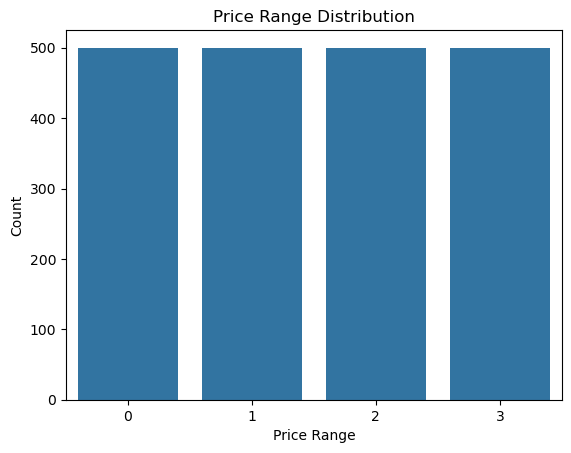

In [9]:
# Distribution of target classes
sns.countplot(x='price_range', data=df)
plt.title('Price Range Distribution')
plt.xlabel('Price Range')
plt.ylabel('Count')
plt.show()

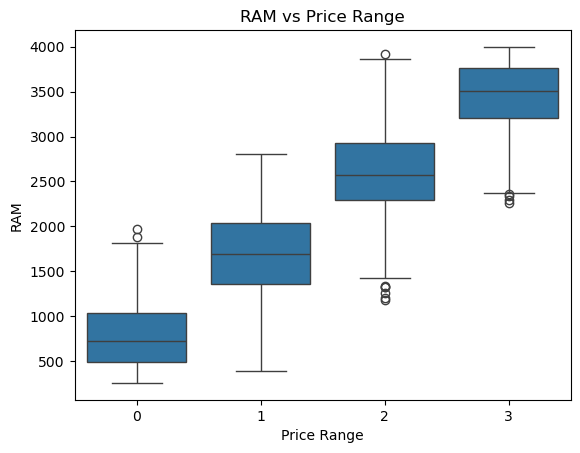

In [10]:
# RAM distribution across price categories
sns.boxplot(x='price_range', y='ram', data=df)
plt.title('RAM vs Price Range')
plt.xlabel('Price Range')
plt.ylabel('RAM')
plt.show()

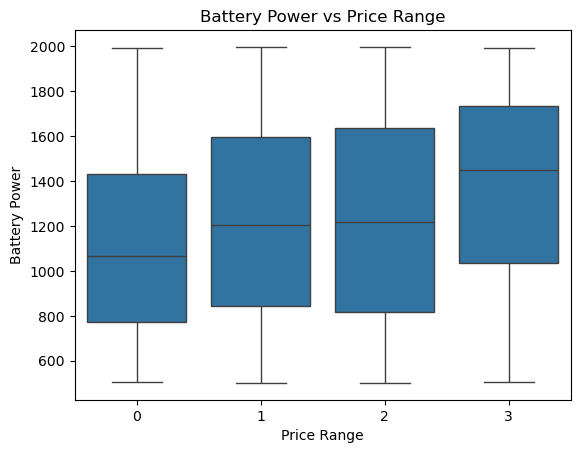

In [11]:
# Battery power distribution across price categories
sns.boxplot(x='price_range', y='battery_power', data=df)
plt.title('Battery Power vs Price Range')
plt.xlabel('Price Range')
plt.ylabel('Battery Power')
plt.show()

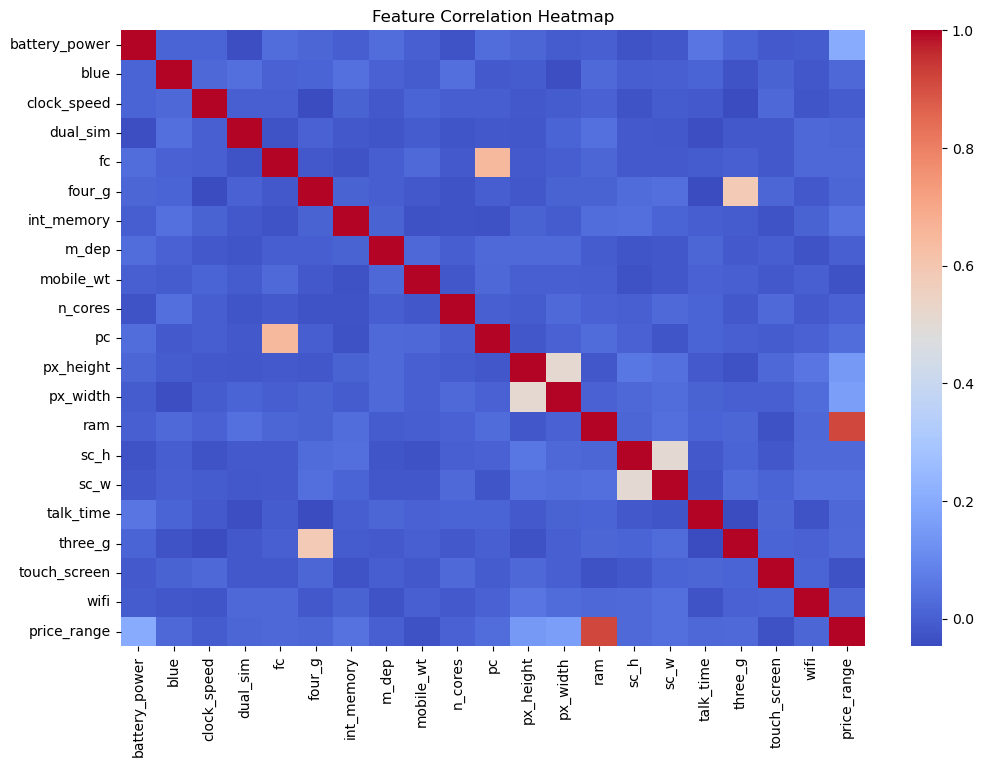

In [12]:
# Correlation heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

## 5. Feature and Target Separation

In [13]:
# Separate input features and target variable
X = df.drop('price_range', axis=1)
y = df['price_range']
print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (2000, 20)
Target Shape: (2000,)


## 6. Train-Test Split

In [14]:
# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
print("X_train Shape:", X_train.shape)
print("X_test Shape :", X_test.shape)
print("y_train Shape:", y_train.shape)
print("y_test Shape :", y_test.shape)

X_train Shape: (1600, 20)
X_test Shape : (400, 20)
y_train Shape: (1600,)
y_test Shape : (400,)


## 7. Feature Scaling

In [15]:
# Standardize feature values
scaler = StandardScaler()

# Scaling training and testing features
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Training Data Shape:", X_train_scaled.shape)
print("Testing Data Shape:", X_test_scaled.shape)

Training Data Shape: (1600, 20)
Testing Data Shape: (400, 20)


## 8. Model Training and Evaluation

### 8.1 Logistic Regression

In [16]:
# Initializing Logistic Regression model
lr = LogisticRegression(random_state=42)

# Training the model
lr.fit(X_train_scaled, y_train)

LogisticRegression(random_state=42)

In [17]:
# Predictions on test data
y_pred_lr = lr.predict(X_test_scaled)

In [18]:
# Accuracy
lr_accuracy = accuracy_score(y_test, y_pred_lr)
print("Accuracy :", lr_accuracy)

Accuracy : 0.965


In [19]:
# Classification report
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.99      0.98      0.98       100
           1       0.96      0.96      0.96       100
           2       0.95      0.94      0.94       100
           3       0.96      0.98      0.97       100

    accuracy                           0.96       400
   macro avg       0.97      0.96      0.96       400
weighted avg       0.97      0.96      0.96       400



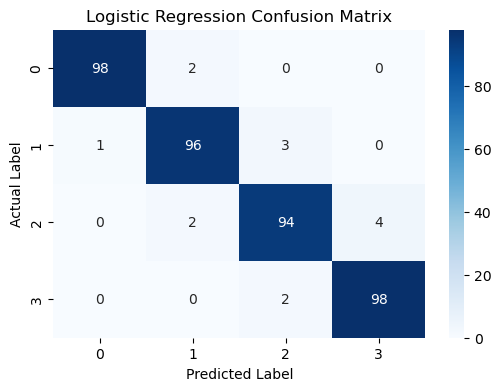

In [20]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred_lr)

# Visualizing confusion matrix
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

### 8.2 Decision Tree Classifier

In [48]:
# Initializing Decision Tree model
dt = DecisionTreeClassifier(random_state=42)

# Training the model
dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [49]:
# Predictions on test data
y_pred_dt = dt.predict(X_test)

In [50]:
# Accuracy
dt_accuracy = accuracy_score(y_test, y_pred_dt)
print("Accuracy :", dt_accuracy)

Accuracy : 0.83


In [53]:
# Classification report
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.88      0.92      0.90       100
           1       0.78      0.74      0.76       100
           2       0.75      0.80      0.77       100
           3       0.92      0.86      0.89       100

    accuracy                           0.83       400
   macro avg       0.83      0.83      0.83       400
weighted avg       0.83      0.83      0.83       400



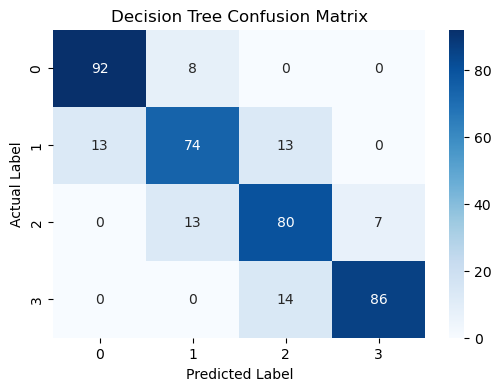

In [52]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Decision Tree Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

### 8.3 Random Forest Classifier

In [54]:
# Initializing Random Forest model
rf_model = RandomForestClassifier(n_estimators=100,random_state=42)

# Training the model
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [55]:
# Predictions on test data
y_pred_rf = rf_model.predict(X_test)

In [56]:
# Accuracy
rf_accuracy = accuracy_score(y_test, y_pred_rf)
print("Accuracy :", rf_accuracy)

Accuracy : 0.88


In [57]:
# Classification report
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.95      0.96      0.96       100
           1       0.82      0.84      0.83       100
           2       0.81      0.79      0.80       100
           3       0.93      0.93      0.93       100

    accuracy                           0.88       400
   macro avg       0.88      0.88      0.88       400
weighted avg       0.88      0.88      0.88       400



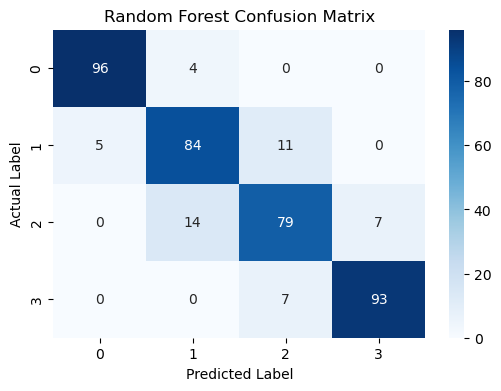

In [58]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,4))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

### 8.4 Support Vector Classifier (SVC)

In [60]:
# Initializing SVC model
svc_model = SVC(random_state=42)

# Training the model
svc_model.fit(X_train_scaled, y_train)

SVC(random_state=42)

In [61]:
# Predictions using SVC model
y_pred_svc = svc_model.predict(X_test_scaled)

In [66]:
# Accuracy
svc_accuracy = accuracy_score(y_test, y_pred_svc)
print("Accuracy :", svc_accuracy)

Accuracy : 0.895


In [63]:
# Classification report
print(classification_report(y_test, y_pred_svc))

              precision    recall  f1-score   support

           0       0.96      0.94      0.95       100
           1       0.87      0.87      0.87       100
           2       0.82      0.87      0.84       100
           3       0.94      0.90      0.92       100

    accuracy                           0.90       400
   macro avg       0.90      0.90      0.90       400
weighted avg       0.90      0.90      0.90       400



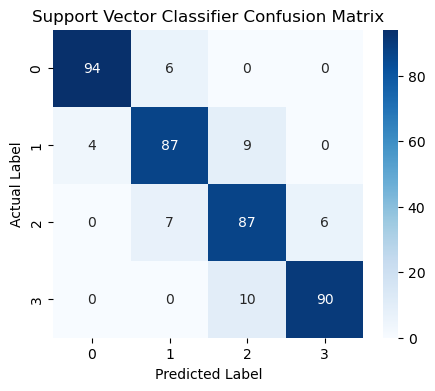

In [64]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred_svc)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Support Vector Classifier Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

## 9. Model Comparison

In [67]:
# Model Comparison Table
comparison = pd.DataFrame({'Model': ['Logistic Regression','Decision Tree Clasifier','Random Forest Classifier','Support Vector Classifier'],
    'Accuracy': [0.965, 0.830, 0.880, 0.895],'Precision': [0.97, 0.83, 0.88, 0.90],'Recall': [0.96, 0.83, 0.88, 0.90],
    'F1 Score': [0.96, 0.83, 0.88, 0.90]})
comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.965,0.97,0.96,0.96
1,Decision Tree Clasifier,0.830,0.83,0.83,0.83
2,Random Forest Classifier,0.880,0.88,0.88,0.88
3,Support Vector Classifier,0.895,0.90,0.90,0.90


## 10. Final Model Selection

Logistic Regression, Decision Tree, Random Forest Classifier and  Support Vector Classifier (SVC) models were trained and evaluated for mobile price prediction.
Among all the models, Logistic Regression achieved the highest accuracy, precision, recall, and F1-score values while correctly classifying the majority of mobiles across all four price categories.
The model achieved an accuracy of 96.5% and produced the fewest misclassifications compared to the other evaluated models.
Since accurately predicting mobile price categories is important for market analysis and pricing strategies, **the Logistic Regression model was selected as the final model for Mobile Phone Price Prediction.**

## 11. Prediction

In [68]:
# Sample mobile data for prediction
sample_mobile = pd.DataFrame({'battery_power': [1500],'blue': [1],'clock_speed': [2.0],'dual_sim': [1],'fc': [8],'four_g': [1],'int_memory': [64],
                              'm_dep': [0.7],'mobile_wt': [150],'n_cores': [8],'pc': [16],'px_height': [1200],'px_width': [1800],'ram': [3500],
                              'sc_h': [16],'sc_w': [8],'talk_time': [18],'three_g': [1],'touch_screen': [1],'wifi': [1]})

# Applying the same scaling used during training
sample_mobile_scaled = scaler.transform(sample_mobile)

prediction = lr.predict(sample_mobile_scaled)
price_labels = {0: "Low Cost",1: "Medium Cost",2: "High Cost",3: "Very High Cost"}
print("Predicted Price Category:", price_labels[prediction[0]])

Predicted Price Category: Very High Cost


In [69]:
# Sample mobile data for prediction (Low Cost)
sample_mobile = pd.DataFrame({'battery_power': [700],'blue': [0],'clock_speed': [0.8],'dual_sim': [0],'fc': [1],'four_g': [0],'int_memory': [8],
                              'm_dep': [0.5],'mobile_wt': [180],'n_cores': [2],'pc': [2],'px_height': [300],'px_width': [600],'ram': [500],
                              'sc_h': [8],'sc_w': [4],'talk_time': [5],'three_g': [0],'touch_screen': [0],'wifi': [0]})

# Applying the same scaling used during training
sample_mobile_scaled = scaler.transform(sample_mobile)

prediction = lr.predict(sample_mobile_scaled)
price_labels = {0: "Low Cost",1: "Medium Cost",2: "High Cost",3: "Very High Cost"}
print("Predicted Price Category:", price_labels[prediction[0]])

Predicted Price Category: Low Cost
